In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set color palette (matches segger plot)
colors = plt.cm.tab10.colors
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

# Load and prepare metrics
df = pd.read_csv("../../metrics.csv")

def smooth(values):
    """Adaptive smoothing: window = max(5, min(25, count // 20))"""
    window = max(5, min(25, len(values) // 20))
    return pd.Series(values).rolling(window, min_periods=1).mean().to_numpy()

# Group metrics
metrics = {}
for col in df.columns:
    if col in ['epoch', 'step']:
        continue
    base = col.split(':')[1] if ':' in col else col
    metrics.setdefault(base, []).append(col)

# Extract data
metrics_data = []
for base, cols in sorted(metrics.items()):
    entries = []
    for col in cols:
        data = df[col].dropna()
        if len(data) > 0:
            x = df['step'][:len(data)].values
            y = smooth(data.values)
            label = 'val' if col.startswith('val:') else 'train'
            entries.append((label, col, x, y))
    if entries:
        metrics_data.append((base, entries))

print(f"Loaded {len(df)} steps, {len(metrics_data)} metric groups")

Loaded 24835 steps, 4 metric groups


## Example Output

From Xenium breast cancer training with v2 multi-task loss:

## Example Output

From Xenium breast cancer training with v2 multi-task loss:

### Matplotlib Plot

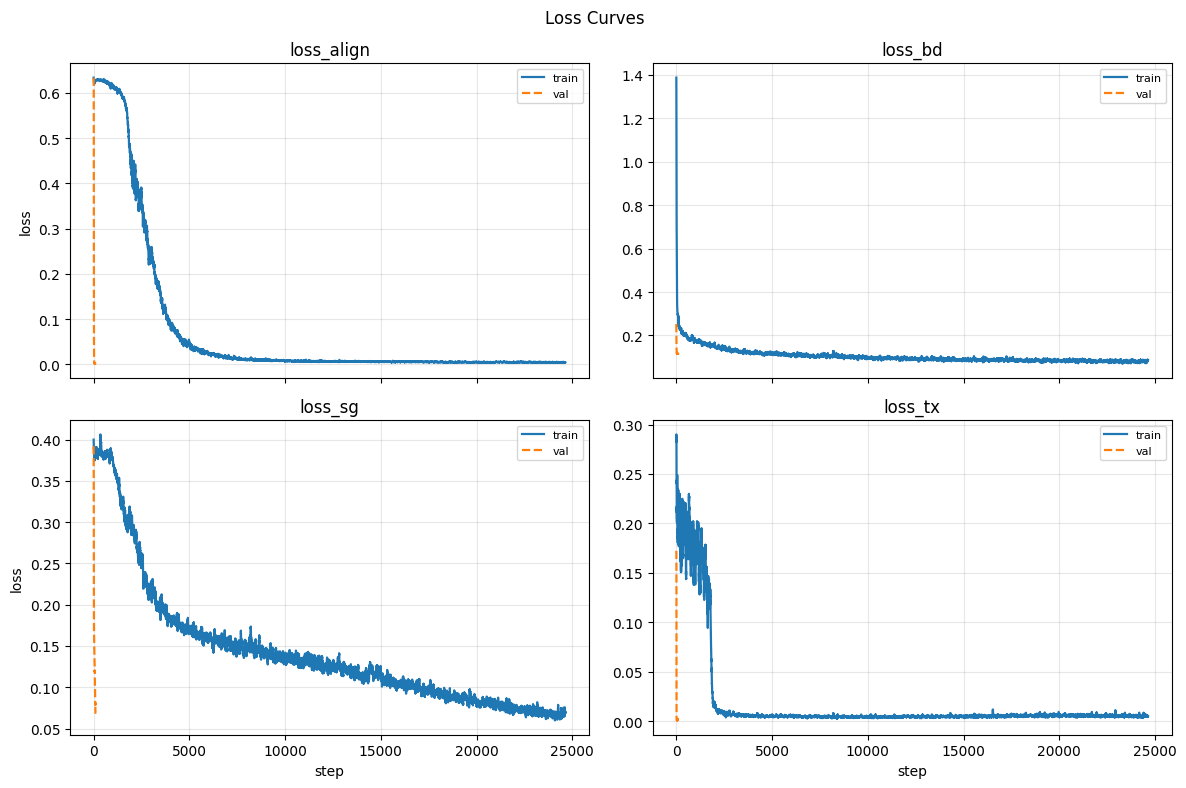

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for idx, (base, entries) in enumerate(metrics_data):
    if idx >= 4:
        break
    ax = axes[idx]
    for label, col, x, y in entries:
        style = '--' if label == 'val' else '-'
        ax.plot(x, y, label=label, linestyle=style, linewidth=1.6)
    ax.set_title(base)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel('step')
axes[0].set_ylabel('loss')
axes[2].set_ylabel('loss')
fig.suptitle('Loss Curves')
fig.tight_layout()
plt.show()

**Features:**
- 4 loss components: `loss_align`, `loss_bd`, `loss_sg`, `loss_tx`
- Solid = train, Dashed = validation
- Auto-smoothed (adaptive window)
- Tab10 color palette

### Terminal Plot (Quick Mode)

In [3]:
try:
    from uniplot import plot as uniplot_plot
    
    for base, entries in metrics_data:
        xs = [e[2] for e in entries]
        ys = [e[3] for e in entries]
        labels = [e[0] for e in entries]
        uniplot_plot(xs=xs, ys=ys, legend_labels=labels,
                     color=True, lines=True, title=base)
        print()
        
except ImportError:
    print("Install: pip install segger[plot]")

                          loss_align
┌────────────────────────────────────────────────────────────┐
│▌█▙▄                                                        │
│▌  ▀▌                                                       │
│▌   ▜                                                       │
│▌   ▐                                                       │ 0.5
│▌   ▐▖                                                      │
│▌   ▝█                                                      │
│▌    █▖                                                     │
│▌    ▐▌                                                     │
│▌     █▖                                                    │
│▌     ▐▌                                                    │
│▌      █                                                    │ 0.2
│▌      ▜▌                                                   │
│▌       ▜                                                   │
│▌       ▐▙                                                  │
│▌        

## Advanced: Smoothing Comparison

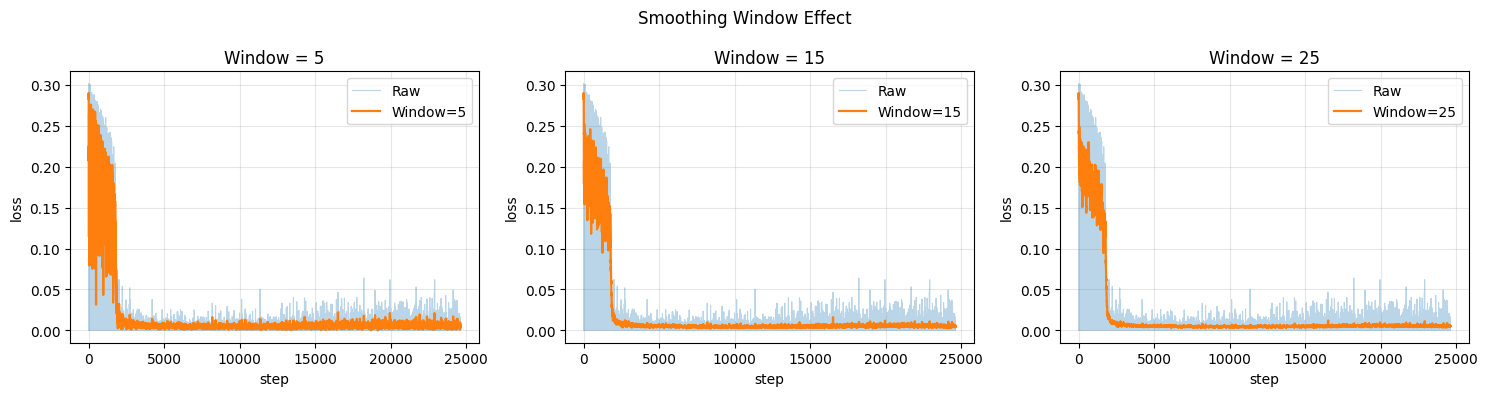

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get raw data
col = 'train:loss_tx'
data = df[col].dropna()
x = df['step'][:len(data)].values
y = data.values

# Compare windows
for ax, w in zip(axes, [5, 15, 25]):
    y_smooth = pd.Series(y).rolling(w, min_periods=1).mean()
    ax.plot(x, y, alpha=0.3, label='Raw', linewidth=0.8)
    ax.plot(x, y_smooth, label=f'Window={w}', linewidth=1.6)
    ax.set_title(f'Window = {w}')
    ax.set_xlabel('step')
    ax.set_ylabel('loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Smoothing Window Effect')
fig.tight_layout()
plt.show()

## Design Notes

**Auto-smoothing:** Window adapts to data length: `max(5, min(25, count // 20))`

**Grouping:** Metrics like `train:loss_tx` and `val:loss_tx` plotted together for easy comparison.

**Step-based:** Uses batch steps (not epochs) for finer granularity.

**Two modes:** 
- matplotlib = High-quality PNG files
- uniplot = Quick terminal checks (SSH-friendly)

**Color palette:** Tab10 for distinct, colorblind-friendly colors.

## Quick Reference

**Healthy training:**
- All losses decreasing ✓
- Train/val tracking closely ✓
- No sharp spikes ✓

**Troubleshooting:**
- Train↓ Val↑ → Overfitting (reduce model size)
- Both flat → Underfitting (increase capacity)
- Spikes → Instability (lower learning rate)

**More info:** `segger plot --help` | `docs/LOSS_FUNCTIONS.md`